In [2]:
import numpy as np
import jax.numpy as jnp

from herculens.Util import param_util

import numpy as np

import jax
import jax.numpy as jnp
from jax_zero_contour import ZeroSolver
from jax import random

from functools import partial

import matplotlib.pyplot as plt

from skimage import measure
from scipy.ndimage import map_coordinates
from scipy.interpolate import splprep, splev

import numpyro
import numpyro.distributions as dist

from herculens.Coordinates.pixel_grid import PixelGrid
from herculens.Instrument.noise import Noise
from herculens.Instrument.psf import PSF

from herculens.MassModel.mass_model import MassModel
from herculens.LightModel.light_model import LightModel
from herculens.LensImage.lens_image import LensImage

from herculens.MassModel.mass_model_multiplane import MPMassModel
from herculens.LightModel.light_model_multiplane import MPLightModel
from herculens.LensImage.lens_image_multiplane import MPLensImage

import os

from astropy.io import fits

/opt/anaconda3/envs/herculensenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
gen = EuclidGenerator("images/", 15)

NameError: name 'EuclidGenerator' is not defined

In [ ]:

lens_EPL_kwargs = {
    'theta_E' : 2.0, 
    'gamma': np.random.uniform(1.7, 2.3),
    'e1': 0.1,
    'e2': 0.1,
    'center_x': 0.0,
    'center_y': 0.0
}
lens_shear_kwargs = {
    'gamma1': np.random.uniform(0.0, 0.3),     
    'gamma2':np.random.uniform(0.0, 0.3),      
    'ra_0': lens_EPL_kwargs['center_x'],
    'dec_0': lens_EPL_kwargs['center_y'],
}
lens_mass_kwargs = [lens_EPL_kwargs, lens_shear_kwargs]

# --- dumy source 1 kwargs --- #
source1_SIS_kwargs = {
    'theta_E' : 0.0, 
    'center_x': 0.0,    
    'center_y': 0.0    
}
source1_shear_kwargs = {
    'gamma1': 0.0,     
    'gamma2': 0.0,      
    'ra_0': 0.0,
    'dec_0': 0.0,
}
source1_mass_kwargs = [source1_SIS_kwargs, source1_shear_kwargs]

mp_mass_kwargs = [lens_mass_kwargs, source1_mass_kwargs]
eta = 2

In [6]:
with os.scandir("lrg_used_for_karina_sim/") as entries:
    lens_files = np.array([item.name for item in entries])

In [17]:
with fits.open("lrg_used_for_karina_sim/" + lens_files[2000]) as hdul:
    print(hdul.info())
    flux = hdul[1].data
    psf = hdul[2].data
    rms = hdul[3].data

Filename: lrg_used_for_karina_sim/EUC_15787_DESI-sel.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   ()      
  1  VIS_FLUX      1 ImageHDU       106   (150, 150)   float32   
  2  VIS_PSF       1 ImageHDU         9   (21, 21)   float32   
  3  VIS_RMS       1 ImageHDU         8   (150, 150)   float32   
  4  NIR_Y_FLUX    1 ImageHDU       105   (150, 150)   float32   
  5  NIR_Y_PSF     1 ImageHDU         9   (33, 33)   float32   
  6  NIR_Y_RMS     1 ImageHDU         8   (150, 150)   float32   
  7  NIR_J_FLUX    1 ImageHDU       105   (150, 150)   float32   
  8  NIR_J_PSF     1 ImageHDU         9   (33, 33)   float32   
  9  NIR_J_RMS     1 ImageHDU         8   (150, 150)   float32   
 10  NIR_H_FLUX    1 ImageHDU       105   (150, 150)   float32   
 11  NIR_H_PSF     1 ImageHDU         9   (33, 33)   float32   
 12  NIR_H_RMS     1 ImageHDU         8   (150, 150)   float32   
None


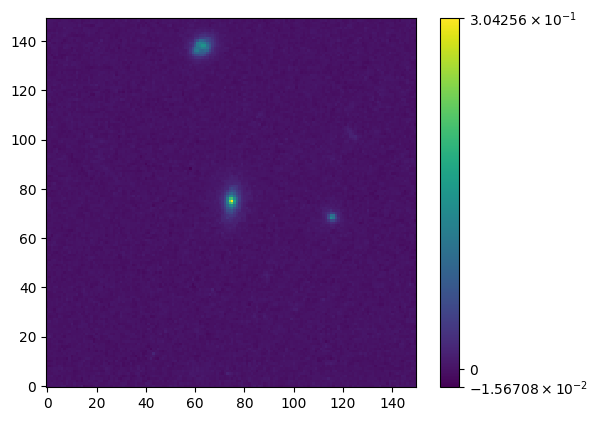

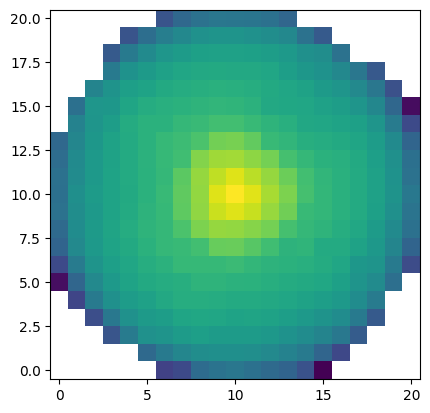

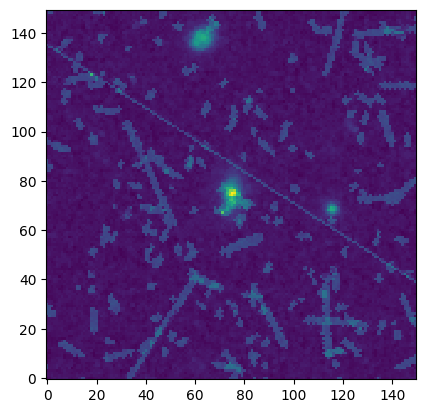

In [19]:
plt.imshow(flux, norm='symlog')
plt.colorbar()
plt.show()

plt.imshow(psf, norm='log')
plt.show()

plt.imshow(rms, norm='log')
plt.show()

In [ ]:
def fwhm_from_moments(image):
    y, x = np.indices(image.shape)

    total = image.sum()
    x0 = (x * image).sum() / total
    y0 = (y * image).sum() / total

    var_x = ((x - x0)**2 * image).sum() / total
    var_y = ((y - y0)**2 * image).sum() / total

    sigma = np.sqrt(0.5 * (var_x + var_y))  # average sigma
    fwhm = 2.355 * sigma
    return fwhm


In [ ]:
print(fwhm_from_moments(psf))

3.7299614191005004


In [ ]:
i = 24

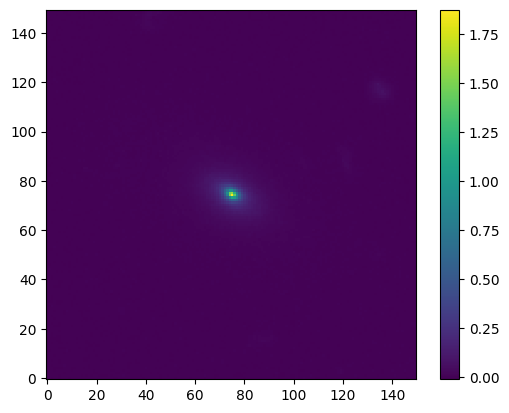

In [ ]:
with fits.open("lrg_used_for_karina_sim/" + lens_files[i]) as hdul:
    image_header = hdul[1].header
    image_data = hdul[1].data
    
    # plt.imshow(image_data, origin='lower', norm='log')
    plt.imshow(image_data, origin='lower')
    plt.colorbar()
    plt.show()


In [ ]:
def get_shape_of_source(source_img, threshold=0.1):
    """
    Calculates the axis ratio and position angle from the image of a source, returns as (e1, e2) ellipticity parameters.
    """

    mask = source_img > (threshold * source_img.max())

    y, x = np.indices(source_img.shape)
    # x, y = source_coords
    I = source_img * mask  # masked image

    # Compute centroid
    x_c = (I * x).sum() / I.sum()
    y_c = (I * y).sum() / I.sum()

    # Centered coordinates
    x_cen = x - x_c
    y_cen = y - y_c

    # Second moments
    Mxx = (I * x_cen**2).sum() / I.sum()
    Myy = (I * y_cen**2).sum() / I.sum()
    Mxy = (I * x_cen * y_cen).sum() / I.sum()

    # Inertia tensor
    M = jnp.array([[Mxx, Mxy],
                  [Mxy, Myy]])

    # Eigen decomposition
    evals, evecs = jnp.linalg.eigh(M)
    order = jnp.argsort(evals)[::-1]
    evals = evals[order]
    evecs = evecs[:, order]

    major, minor = jnp.sqrt(evals)
    axis_ratio = minor / major
    pos_angle = jnp.arctan2(evecs[1, 0], evecs[0, 0])  # radians
    
    e1_src, e2_src = param_util.phi_q2_ellipticity(pos_angle, axis_ratio)

    return e1_src, e2_src

0.7160828 -28.966253


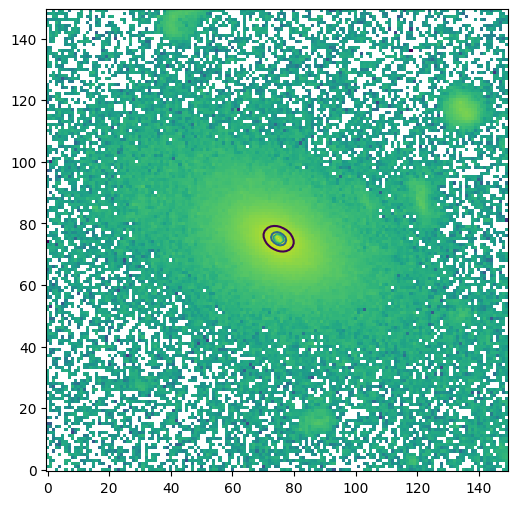

In [ ]:
e1, e2 = get_shape_of_source(source_img=image_data[70:90, 70:90])
# e1, e2 = get_shape_of_source(source_img=image_data[60:100, 60:100])

phi, q = param_util.ellipticity2phi_q(e1, e2)
phi = np.degrees(phi)

print(q, phi)

mm = MassModel(["EPL"])

lens_EPL_kwargs = {
    "theta_E" : 1.0,
    "gamma" : 2.0,
    "e1" : e1,
    "e2" : e2,
    "center_x" : 0.0,
    "center_y" : 0.0
}

lens_mass_kwargs = [lens_EPL_kwargs]

x_vec = np.linspace(-17, 17, image_data.shape[0])
y_vec = np.linspace(-17, 17, image_data.shape[0])
X, Y = np.meshgrid(x_vec, y_vec)

kappa = mm.kappa(X, Y, lens_mass_kwargs)

plt.figure(figsize=(6,6))

plt.imshow(image_data, norm="log", origin="lower")
# plt.imshow(image_data, origin="lower")
plt.contour(kappa, norm="log", origin="lower")
plt.savefig("images/example_of_bad_fit.png")
plt.show()

In [ ]:
theta_pdf = np.load("data/theta_pdf.npy")
theta_pdf = theta_pdf[theta_pdf[:, 0] > 0.5]

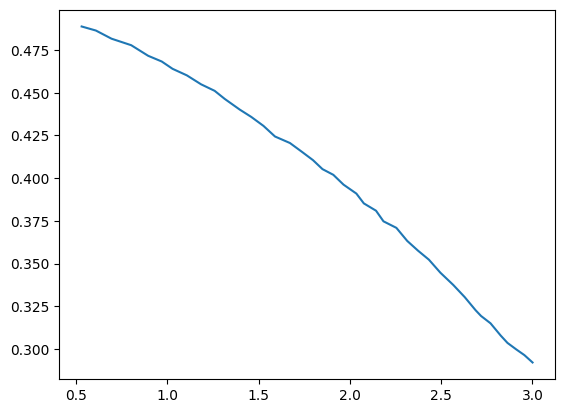

In [ ]:
plt.plot(*theta_pdf.T)
plt.show()

In [ ]:
from scipy.integrate import simpson

In [ ]:
I = simpson(theta_pdf[:, 1], theta_pdf[:, 0])
theta_pdf[:, 1] = theta_pdf[:, 1]/I

In [ ]:
print(I)

0.9999999999999999


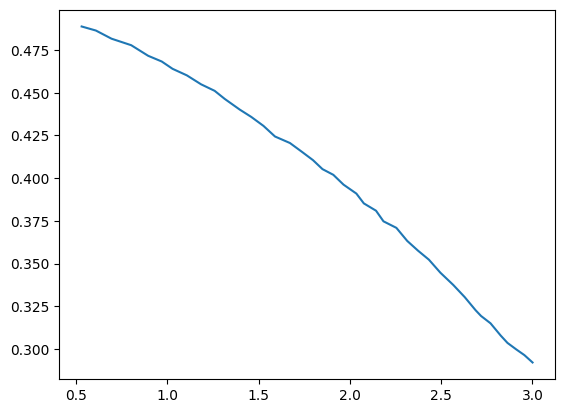

In [ ]:
plt.plot(*theta_pdf.T)
plt.show()

# np.save("data/theta_pdf.npy", theta_pdf)

In [ ]:
pip install shapely

/opt/anaconda3/envs/herculensenv/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("data/mer_morphology.csv")
df.head()

,object_id,sersic_sersic_vis_radius,sersic_sersic_vis_radius_err,sersic_sersic_vis_axis_ratio,sersic_sersic_vis_axis_ratio_err,sersic_sersic_vis_index,sersic_sersic_vis_index_err
0,-861556546086816217,0.453454,NaN,0.503762,6.952702e-16,1.0,3.180944e-15
1,-861553116086842109,0.273688,NaN,0.854680,4.859626e-09,1.0,NaN
2,-861547479086786330,0.661196,2.971129e-28,0.523952,NaN,1.0,1.771724e-17
3,-861546201086797146,0.435250,NaN,0.627471,NaN,1.0,5.351905e-11
4,-861544581086737122,1.065573,2.187752e-26,0.216091,NaN,1.0,1.718850e-15


In [ ]:
data = df['sersic_sersic_vis_radius']

In [ ]:
mu = np.mean(data)
sigma = np.std(data)

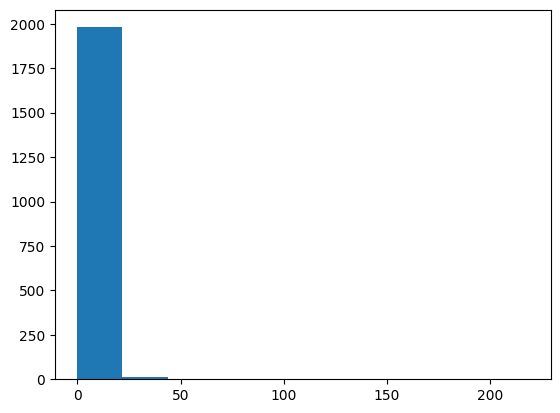

In [ ]:
plt.hist(data)
plt.show()

In [ ]:
print(mu, sigma)

1.9820387460576312 10.150474658688365


In [ ]:
model = LightModel(["SERSIC_ELLIPSE", "MULTIPOLE", "MULTIPOLE"])

In [ ]:
sersic_kwargs = {
    'amp' : 1600,
    'R_sersic' : 5.2195454,
    'n_sersic' : 0.11295909,
    'e1' : -0.26188686,
    'e2' : -0.00066537,
    'center_x' : -0.03208198,
    'center_y' : 0.01709593
}
multipole3_kwargs = {
    'm' : 3,
    'amp_m' : 499.46738,
    'phi_m' : 1.6339368,
    'center_x' : -0.03208198,
    'center_y' : 0.01709593
}
multipole4_kwargs = {
    'm': 4.0, 
    'amp_m': 209.16472, 
    'phi_m': 0.71709037,
    'center_x': -0.03208198, 
    'center_y': 0.01709593
}

light_kwargs = [sersic_kwargs, multipole3_kwargs, multipole4_kwargs]

In [ ]:
sersic_kwargs = {
    'amp' : 1600,
    'R_sersic' : 5.2195454,
    'n_sersic' : 0.11295909,
    'e1' : -0.26188686,
    'e2' : -0.00066537,
    'center_x' : -0.03208198,
    'center_y' : 0.01709593
}
multipole3_kwargs = {
    'm' : 3,
    'amp_m' : 499.46738,
    'phi_m' : 1.6339368,
    'center_x' : -0.03208198,
    'center_y' : 0.01709593
}
multipole4_kwargs = {
    'm': 4.0, 
    'amp_m': 209.16472, 
    'phi_m': 0.71709037,
    'center_x': -0.03208198, 
    'center_y': 0.01709593
}

light_kwargs = [sersic_kwargs, multipole3_kwargs, multipole4_kwargs]

In [ ]:
x_vec = np.linspace(-10, 10, 100)
y_vec = np.linspace(-10, 10, 100)

X, Y = np.meshgrid(x_vec, y_vec)
light = model.surface_brightness(X, Y, light_kwargs)

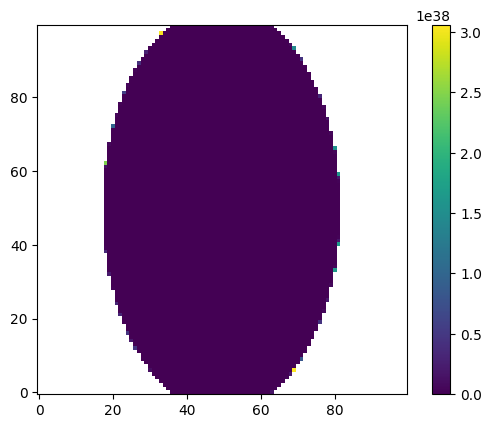

In [ ]:
plt.imshow(light)
plt.colorbar()
plt.show()

In [ ]:
print(random)

<module 'jax.random' from '/opt/anaconda3/envs/herculensenv/lib/python3.11/site-packages/jax/random.py'>


In [ ]:
from functools import partial

@partial(jax.jit, static_argnums=(5,))
def P_Matern(k, n, sigma, rho, c=1e-20, k_zero=None):
    '''
    Power spectrum for the Matern covariance kernel.

    The covariance follows:
    C_n(d) = [(sigma^2 * 2^(1-n)) / Gamma(n)] * [sqrt(2*n) * d/rho]^n * K_n(sqrt(2*n) * d/rho)

    And the (2D) power spectrum follows:
    P(k) = sigma^2 * 4 * pi * n * (2 *n/rho^2)^n * [(2 *n/rho^2) + k^2]^-(n + 1)

    https://en.wikipedia.org/wiki/Mat%C3%A9rn_covariance_function

    parameters
    ----------
    k: spatial frequency
    n: "clumpy-ness" factor, smaller values lead to more small scale
        variation
    sigma: amplitude
    rho: large scale correlation length
    c: small scale power
    '''
    r = (2 * n / rho**2)
    norm = sigma**2 * 4 * jnp.pi * n * jnp.power(r, n)
    P = norm * jnp.power(r + k**2, -(n + 1))  # + c
    if k_zero is not None:
        P = jnp.where(k == 0, k_zero, P)
    return P

In [ ]:
from numpyro.distributions.util import lazy_property

class K_grid():
    def __init__(self, shape, scale=1):
        '''
        Helper class for constructing a K grid for 2d FFTs or rFFTs.

        parameters
        ----------
        shape: tuple containing the shape of the image being FFTd
            (Ny, Nx)
        scale: (optional) physical size for each pixel, default=1
            (e.g. all sizes are in units of pixels)
        '''
        self.Ny, self.Nx = shape
        self.scale = scale

    @lazy_property
    def rk(self):
        '''Construct the *independent* spatial frequencies for a 2D real-FFT'''
        kx = 2 * np.pi * np.fft.rfftfreq(self.Nx, d=self.scale)
        ky = 2 * np.pi * np.fft.fftfreq(self.Ny, d=self.scale)
        return np.sqrt(ky.reshape(-1, 1)**2 + kx**2)

    @lazy_property
    def k(self):
        '''Construct all the spatial frequencies for a 2D FFT'''
        kx = 2 * np.pi * np.fft.fftfreq(self.Nx, d=self.scale)
        ky = 2 * np.pi * np.fft.fftfreq(self.Ny, d=self.scale)
        return np.sqrt(ky.reshape(-1, 1)**2 + kx**2)

In [ ]:
@partial(jax.jit, static_argnums=(1,))
def even_pack(values, N):
    '''Pack the value for an even-by-even FFT'''
    n1 = N//2 + 1
    thin_real = jax.lax.dynamic_slice(values, (0, 1), (N, n1 - 2))
    thin_imag = jnp.flip(jax.lax.dynamic_slice(values, (0, n1), (N, n1 - 2)), axis=1)

    first_real_slice = jax.lax.dynamic_slice(values, (1, 0), (n1 - 2, 1))
    first_real = jnp.vstack([
        2 * jax.lax.dynamic_slice(values, (0, 0), (1, 1)),
        first_real_slice,
        2 * jax.lax.dynamic_slice(values, (n1 - 1, 0), (1, 1)),
        jnp.flip(first_real_slice, axis=0)
    ])

    last_real_slice = jax.lax.dynamic_slice(values, (1, n1 - 1), (n1 - 2, 1))
    last_real = jnp.vstack([
        2 * jax.lax.dynamic_slice(values, (0, n1 - 1), (1, 1)),
        last_real_slice,
        2 * jax.lax.dynamic_slice(values, (n1 - 1, n1 - 1), (1, 1)),
        jnp.flip(last_real_slice, axis=0)
    ])

    first_imag_slice = jax.lax.dynamic_slice(values, (n1, 0), (n1 - 2, 1))
    first_imag = jnp.vstack([
        jnp.zeros((1, 1)),
        -jnp.flip(first_imag_slice, axis=0),
        jnp.zeros((1, 1)),
        first_imag_slice
    ])

    last_imag_slice = jax.lax.dynamic_slice(values, (n1, n1 - 1), (n1 - 2, 1))
    last_imag = jnp.vstack([
        jnp.zeros((1, 1)),
        -jnp.flip(last_imag_slice, axis=0),
        jnp.zeros((1, 1)),
        last_imag_slice
    ])

    delta = thin_real.shape[0] - first_real.shape[0]
    first_real = jnp.pad(first_real, ((0, delta), (0, 0)))
    last_real = jnp.pad(last_real, ((0, delta), (0, 0)))
    first_imag = jnp.pad(first_imag, ((0, delta), (0, 0)))
    last_imag = jnp.pad(last_imag, ((0, delta), (0, 0)))

    fft_real = jnp.hstack([first_real, thin_real, last_real])
    fft_imag = jnp.hstack([first_imag, thin_imag, last_imag])
    return fft_real + 1j * fft_imag

@partial(jax.jit, static_argnums=(1,))
def odd_pack(values, N):
    '''Pack the value for an odd-by-odd FFT'''
    n1 = N//2 + 1
    thin_real = jax.lax.dynamic_slice(values, (0, 1), (N, n1 - 1))
    thin_imag = jnp.flip(jax.lax.dynamic_slice(values, (0, n1), (N, n1 - 1)), axis=1)

    first_real_slice = jax.lax.dynamic_slice(values, (1, 0), (n1 - 1, 1))
    first_real = jnp.vstack([
        2 * values[0, 0].reshape(1, 1),
        first_real_slice,
        jnp.flip(first_real_slice, axis=0)
    ])

    first_imag_slice = jax.lax.dynamic_slice(values, (n1, 0), (n1 - 1, 1))
    first_imag = jnp.vstack([
        jnp.zeros((1, 1)),
        -jnp.flip(first_imag_slice, axis=0),
        first_imag_slice,
    ])

    fft_real = jnp.hstack([first_real[:thin_real.shape[0]], thin_real])
    fft_imag = jnp.hstack([first_imag[:thin_imag.shape[0]], thin_imag])
    return fft_real + 1j * fft_imag

@jax.jit
def pack_fft_values(values):
    '''
    Take values in a NxN array and re-arange them into
    the shape of the output of rFFT on an array of the
    same size by adding in the correct symmetries that
    come from a real image input.

    Doing this on a grid of values drawn from a standard
    Normal will result in the rFFT of a white noise image.

    This is used for drawing a white noise FFT in Fourier
    space so it can be "colored" by a power spectrum
    directly.

    parameters
    ----------
    values: The values to be packed, must be a square array
    '''
    Ny, Nx = values.shape
    assert Ny == Nx, 'Input array must be square'
    even_pack_n = partial(even_pack, N=Nx)
    odd_pack_n = partial(odd_pack, N=Nx)
    return jax.lax.cond(
        Nx % 2 == 0,
        even_pack_n,
        odd_pack_n,
        jnp.sqrt(0.5) * values
    )

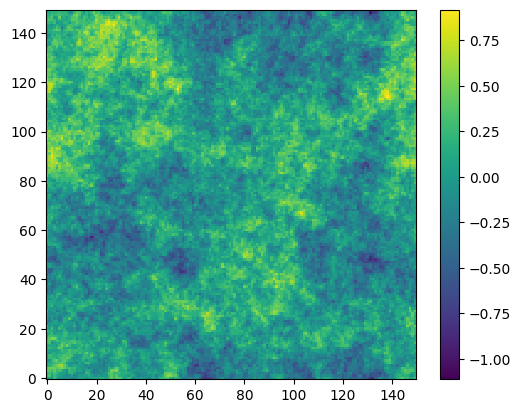

In [ ]:
n = 0.1
sigma = 0.36
rho = 30


k_grid = K_grid(shape=(150,150), scale=1)
P = P_Matern(k_grid.k, n, sigma, rho, k_zero=0)

scale = jnp.sqrt(P)
np.random.seed(0)
white_noise = np.random.normal(0, 1, (150,150))

pixels = jnp.fft.irfft2(pack_fft_values(white_noise*scale), s=scale.shape, norm="ortho")

plt.imshow(pixels)
plt.colorbar()
plt.show()

[[  0.        178.47856    56.375786  ...  18.837301   56.375786
  178.47856  ]
 [178.47856   112.4626     42.926834  ...  16.019438   42.926834
  112.4626   ]
 [ 56.375786   42.926834   22.469755  ...  10.529085   22.469755
   42.926834 ]
 ...
 [ 18.837301   16.019438   10.529085  ...   6.0846066  10.529085
   16.019438 ]
 [ 56.375786   42.926834   22.469755  ...  10.529085   22.469755
   42.926834 ]
 [178.47856   112.4626     42.926834  ...  16.019438   42.926834
  112.4626   ]]
(150, 150)


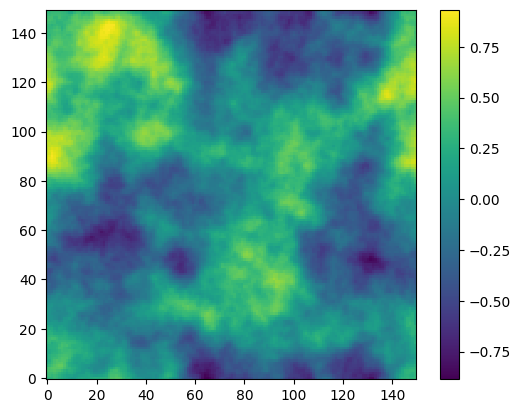

In [ ]:
n = 1
sigma = 0.36
rho = 20


k_grid = K_grid(shape=(150,150), scale=1)
P = P_Matern(k_grid.k, n, sigma, rho, k_zero=0)
print(P)
print(P.shape)

scale = jnp.sqrt(P)
np.random.seed(0)
white_noise = np.random.normal(0, 1, (150,150))

pixels = jnp.fft.irfft2(pack_fft_values(white_noise*scale), s=scale.shape, norm="ortho")
# pixels = jax.nn.softplus(pixels*100)/100

plt.imshow(pixels)
plt.colorbar()
plt.show()

In [ ]:
plot_power_spectrum_2d(pixels)

NameError: name 'plot_power_spectrum_2d' is not defined

In [ ]:
lm = LightModel(['SERSIC_ELLIPSE'])
light_kwargs = [{
    'amp' : 1,
    'R_sersic' : 1,
    'n_sersic' : 5,
    'e1' : 0.1,
    'e2' : 0.1,
    'center_x':0.0,
    'center_y':0.0
}]
x_vec = np.linspace(-5, 5, 150)
y_vec = np.linspace(-5, 5, 150)
X, Y = np.meshgrid(x_vec, y_vec)
image = lm.surface_brightness(X, Y, light_kwargs)

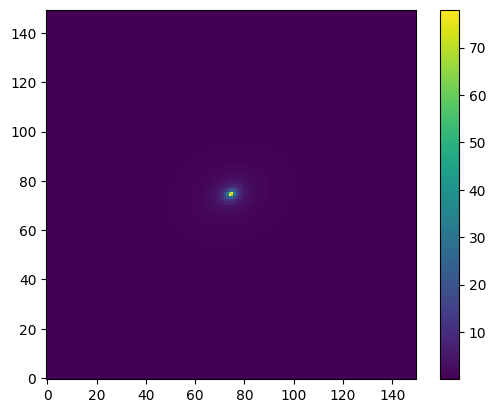

In [ ]:
plt.imshow(image)
plt.colorbar()
plt.show()

In [ ]:
pixels += np.abs(np.min(pixels))
pixels /= np.max(pixels)

In [ ]:
img = image * pixels

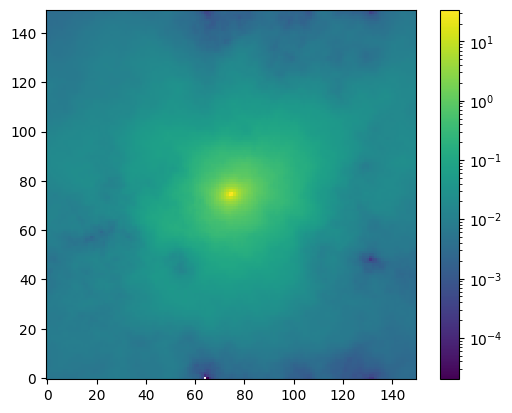

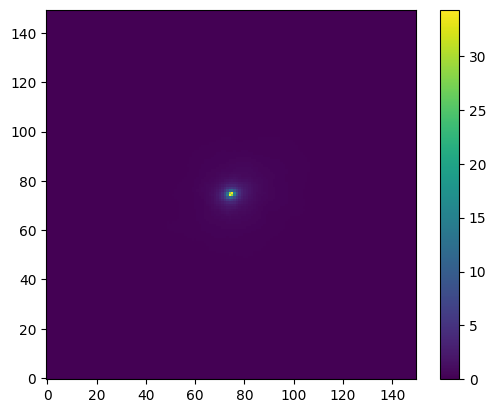

In [ ]:
plt.imshow(img, norm="log")
plt.colorbar()
plt.show()

plt.imshow(img)
plt.colorbar()
plt.show()

In [ ]:
print(k_grid.k.shape)
print(P.shape)

(150, 150)
(150, 150)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_power_spectrum_2d(image, pixel_scale=1.0):
    """
    Compute and plot the radially averaged power spectrum of a 2D array.

    Parameters
    ----------
    image : 2D numpy array
        Input image or field.
    pixel_scale : float
        Physical size per pixel (optional, default=1).
    """

    # Remove mean (important!)
    image = image - np.mean(image)

    ny, nx = image.shape

    # Fourier transform
    fft = np.fft.fft2(image)
    fft = np.fft.fftshift(fft)

    power2d = np.abs(fft)**2

    # Frequency coordinates
    kx = np.fft.fftshift(np.fft.fftfreq(nx, d=pixel_scale))
    ky = np.fft.fftshift(np.fft.fftfreq(ny, d=pixel_scale))
    kx, ky = np.meshgrid(kx, ky)

    k = np.sqrt(kx**2 + ky**2)

    # Radial binning
    k_flat = k.ravel()
    power_flat = power2d.ravel()

    k_bins = np.linspace(0, k_flat.max(), min(nx, ny)//2)
    k_centers = 0.5 * (k_bins[1:] + k_bins[:-1])

    power_radial = np.zeros(len(k_centers))

    for i in range(len(k_centers)):
        mask = (k_flat >= k_bins[i]) & (k_flat < k_bins[i+1])
        if np.any(mask):
            power_radial[i] = power_flat[mask].mean()

    # Plot
    plt.figure()
    plt.loglog(k_centers, power_radial)
    plt.xlabel("k")
    plt.ylabel("P(k)")
    plt.title("Radially Averaged Power Spectrum")
    plt.grid(True, which="both")
    plt.show()

    return k_centers, power_radial

In [ ]:
scale = jnp.sqrt(P)
white_noise = np.random.normal(0, 1, (150,150))

pixels = jnp.fft.irfft2(pack_fft_values(white_noise*scale), s=scale.shape, norm="ortho")

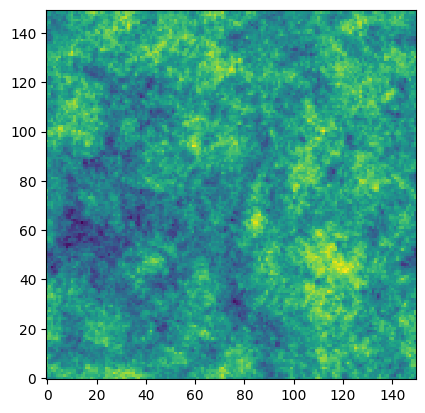

In [ ]:
plt.imshow(pixels)
plt.show()

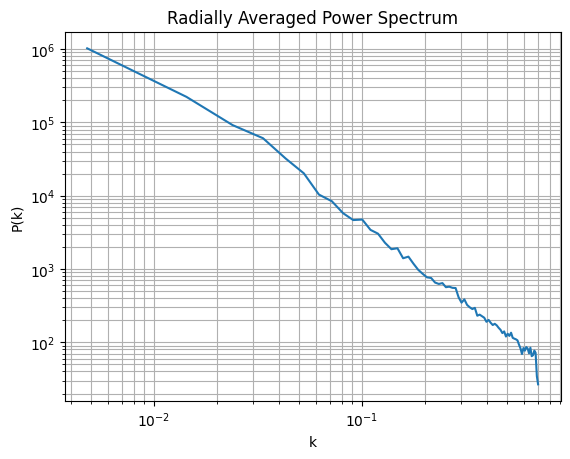

(array([0.00477775, 0.01433325, 0.02388874, 0.03344424, 0.04299974,
        0.05255523, 0.06211073, 0.07166623, 0.08122172, 0.09077722,
        0.10033272, 0.10988822, 0.11944371, 0.12899921, 0.13855471,
        0.1481102 , 0.1576657 , 0.1672212 , 0.1767767 , 0.18633219,
        0.19588769, 0.20544319, 0.21499868, 0.22455418, 0.23410968,
        0.24366517, 0.25322067, 0.26277617, 0.27233167, 0.28188716,
        0.29144266, 0.30099816, 0.31055365, 0.32010915, 0.32966465,
        0.33922015, 0.34877564, 0.35833114, 0.36788664, 0.37744213,
        0.38699763, 0.39655313, 0.40610862, 0.41566412, 0.42521962,
        0.43477512, 0.44433061, 0.45388611, 0.46344161, 0.4729971 ,
        0.4825526 , 0.4921081 , 0.50166359, 0.51121909, 0.52077459,
        0.53033009, 0.53988558, 0.54944108, 0.55899658, 0.56855207,
        0.57810757, 0.58766307, 0.59721857, 0.60677406, 0.61632956,
        0.62588506, 0.63544055, 0.64499605, 0.65455155, 0.66410704,
        0.67366254, 0.68321804, 0.69277354, 0.70

In [ ]:
plot_power_spectrum_2d(pixels)

In [ ]:
mm = MassModel(["SIS", "SHEAR"])
kwargs_SIS = {
    'theta_E' : 0.5446168,
    'center_x' : 0.032781340181827545,
    'center_y' : 0.22142401337623596
}
kwargs_SHEAR = {
    'gamma1' : 0.2648,
    'gamma2' : 0.1899,
    'ra_0' : 0.032781340181827545,
    'dec_0' : 0.22142401337623596
}
kwargs = [kwargs_SIS, kwargs_SHEAR]

x_vec = np.linspace(-7.45, 7.5, 150)
y_vec = np.linspace(-7.45, 7.5, 150)
X, Y = np.meshgrid(x_vec, y_vec)
kappa = mm.kappa(X, Y, kwargs)

In [ ]:
mm = MassModel(["EPL", "SHEAR"])
kwargs_SIS = {
    'theta_E' : 0.5446168,
    'gamma' : 2.0,
    'e1' : 0.0,
    'e2' : 0.0,
    'center_x' : 0.032781340181827545,
    'center_y' : 0.22142401337623596
}
kwargs_SHEAR = {
    'gamma1' : 0.2648,
    'gamma2' : 0.1899,
    'ra_0' : 0.032781340181827545,
    'dec_0' : 0.22142401337623596
}
kwargs = [kwargs_SIS, kwargs_SHEAR]

x_vec = np.linspace(-7.45, 7.5, 150)
y_vec = np.linspace(-7.45, 7.5, 150)
X, Y = np.meshgrid(x_vec, y_vec)
kappa = mm.kappa(X, Y, kwargs)

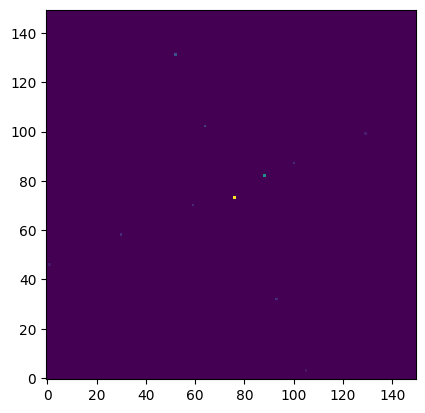

In [ ]:
plt.imshow(kappa)
plt.show()